In [4]:
# %pip install nibabel
# %pip install tqdm
# %pip install matplotlib
# %pip install opencv-python
# %pip install scikit-learn
#%pip install pydot
#%pip install graphviz

#  Data Loading

In [5]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from tqdm import tqdm 
import cv2
from keras.models import load_model

# .nii images
import nibabel as nib

In [6]:
# verify that the GPU is detected by TensorFlow
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


## Funciones generales

In [7]:
# Muestra la máscara superpuesta en la imagen original
def show_image_with_mask(image, mask):
    _, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Imagen Original')
    axes[0].axis('off')

    overlay = np.ma.masked_where(mask == 0, mask)
    axes[1].imshow(image, cmap='gray')
    axes[1].imshow(overlay, cmap='hsv', alpha=0.5)
    axes[1].set_title('Máscara Superpuesta')
    axes[1].axis('off')

    plt.show()

# Muestra la máscara superpuesta en la imagen original
def show_image_masks(image, true_mask, pred_mask):
    _, axes = plt.subplots(1, 3, figsize=(18, 6))

    #Imagen original
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Imagen Original')
    axes[0].axis('off')
    
    #Superposición mascara verdadera
    true_overlay = np.ma.masked_where(true_mask == 0, true_mask)
    axes[1].imshow(image, cmap='gray')
    axes[1].imshow(true_overlay, cmap='hsv', alpha=0.5)
    axes[1].set_title('Máscara Verdadera Superpuesta')
    axes[1].axis('off')

    #Superposición máscara predicha
    pred_overlay = np.ma.masked_where(pred_mask == 0, pred_mask)
    axes[2].imshow(image, cmap='gray')
    axes[2].imshow(pred_overlay, cmap='hsv', alpha=0.5)
    axes[2].set_title('Máscara Predicha Superpuesta')
    axes[2].axis('off')
    plt.show()

## Carga de las imagenes

In [8]:
data_path = 'C:/Users/crist/OneDrive/Desktop/universidad/octavo/tesis/data_objetivo/'

In [9]:
imgs_path = data_path + '/images2/'
mask_path = data_path + '/masks_covid/'

img_list = []
mask_list = []
img_name_list = []

for img_path in tqdm(os.listdir(imgs_path)):

  #Carga del estudio con las imagenes de un paciente
  im_e = nib.load(imgs_path+img_path).get_fdata()

  #Carga de las mascaras del estudio
  ms_e = nib.load(mask_path+img_path).get_fdata()
  
  #Cantidad de imagenes del estudio
  cant_im = im_e.shape[-1]

  for i in range(cant_im):
    
    # Se obtiene cada imagen y su respectiva mascara de cada estudio
    im= im_e[:, :, i]
    ms = ms_e[:, :, i]
   

    # Sumar la cantidad de pixeles de la mascara que son 1
    if np.sum(ms) > 0:
      if 'coronacases'in img_path:
        img_list.append(im)
        img_name_list.append(img_path+'_'+str(i))
        mask_list.append(ms)

print( "# imágenes cargadas: ", len(img_list))
print( "# máscaras cargadas: ", len(mask_list))
    

100%|██████████| 20/20 [00:09<00:00,  2.08it/s]

# imágenes cargadas:  1351
# máscaras cargadas:  1351


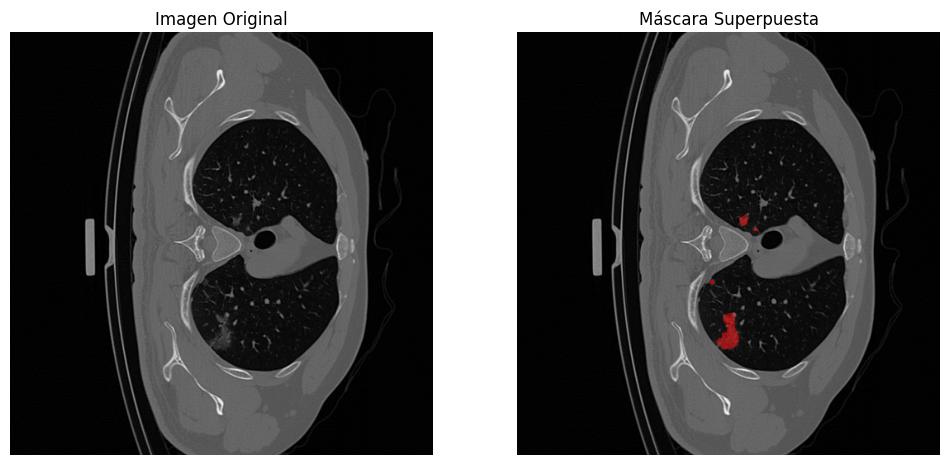

In [10]:
# Visualizar una imagen con su máscara
n=1000
img_prueba = img_list[n]
msk_prueba = mask_list[n]
show_image_with_mask(img_prueba, msk_prueba)

In [11]:
def normalize(image, min_value=-1000, max_value=200):

    img_clipped = np.clip(image, min_value, max_value)
    img_normalized = (img_clipped - min_value) / (max_value - min_value)

    return img_normalized

# Normalizar las imágenes
#img_list = [normalize(img) for img in img_list]

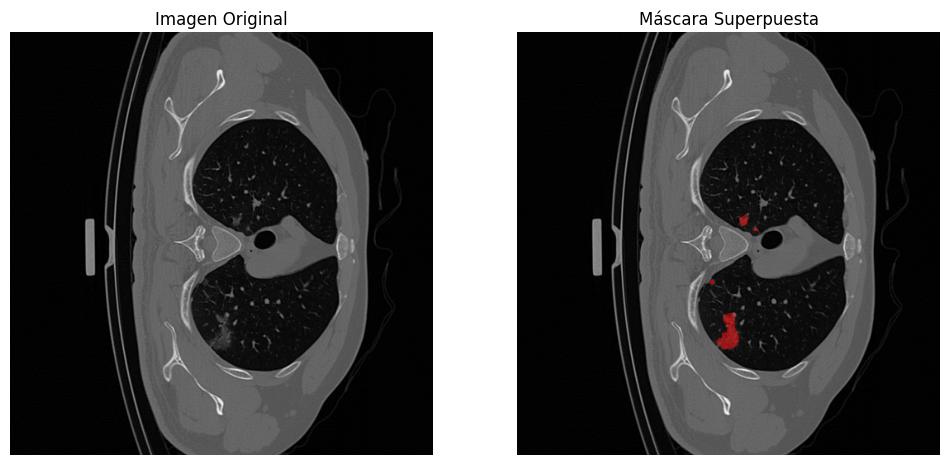

In [12]:
# Visualizar la imagen normalizada
img_prueba = img_list[n]
msk_prueba = mask_list[n]
show_image_with_mask(img_prueba, msk_prueba)

(array([1.15964e+05, 1.71490e+04, 1.97770e+04, 7.78500e+03, 3.16200e+03,
        1.69000e+03, 1.20400e+03, 9.01000e+02, 7.51000e+02, 6.95000e+02,
        6.35000e+02, 5.73000e+02, 5.73000e+02, 5.40000e+02, 5.37000e+02,
        1.13700e+03, 1.22370e+04, 1.28330e+04, 1.03110e+04, 2.71060e+04,
        1.63720e+04, 2.73900e+03, 1.09600e+03, 7.69000e+02, 7.63000e+02,
        8.69000e+02, 6.76000e+02, 5.83000e+02, 4.15000e+02, 3.52000e+02,
        2.93000e+02, 2.60000e+02, 2.43000e+02, 1.93000e+02, 1.70000e+02,
        1.62000e+02, 1.31000e+02, 1.29000e+02, 7.60000e+01, 6.70000e+01,
        5.50000e+01, 2.10000e+01, 2.60000e+01, 2.70000e+01, 3.00000e+01,
        2.50000e+01, 1.90000e+01, 1.50000e+01, 4.00000e+00, 4.00000e+00]),
 array([-1021.  ,  -966.78,  -912.56,  -858.34,  -804.12,  -749.9 ,
         -695.68,  -641.46,  -587.24,  -533.02,  -478.8 ,  -424.58,
         -370.36,  -316.14,  -261.92,  -207.7 ,  -153.48,   -99.26,
          -45.04,     9.18,    63.4 ,   117.62,   171.84,   226.

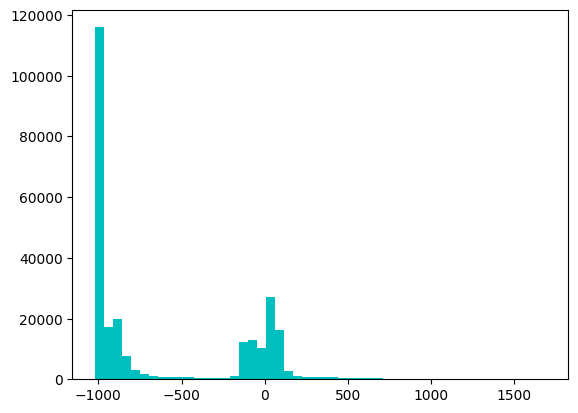

In [13]:
plt.hist(img_prueba.flatten(), bins=50, color='c')

# Preprocessing

### Modificación de las imágenes a la resolución de trabajo 

In [14]:
# Resolución de trabajo
img_size = 128

# Función para redimensionar las imágenes y las máscaras
def resize_image(image, mask, width, height):
    image_resized = tf.keras.preprocessing.image.smart_resize(image, (width, height), interpolation='bilinear')
    mask_resized = tf.keras.preprocessing.image.smart_resize(mask, (width, height), interpolation='bilinear')
    return image_resized, mask_resized

# Redimensionar las imágenes y las máscaras
for i in tqdm(range(len(img_list))):

    img = np.expand_dims(img_list[i], axis=-1)

    msk = np.expand_dims(mask_list[i], axis=-1)

    img_list[i], mask_list[i] = resize_image(img, msk, img_size, img_size)

print("Imágenes redimensionadas: ", len(img_list))
print("Máscaras redimensionadas: ", len(mask_list))

100%|██████████| 1351/1351 [00:18<00:00, 73.81it/s]

Imágenes redimensionadas:  1351
Máscaras redimensionadas:  1351


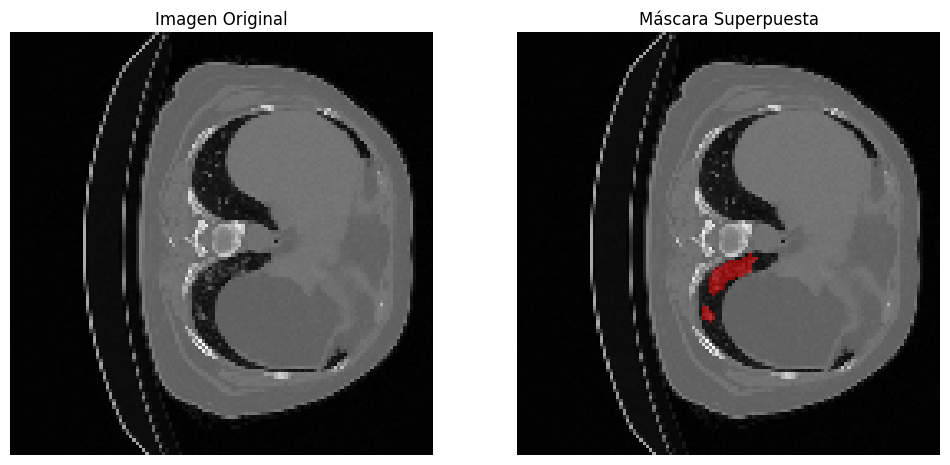

In [15]:
# Visualizar una imagen redimensionada con su máscara
n_prueba = 10
img = img_list[n_prueba]
msk = mask_list[n_prueba]
msk = (msk > 0).astype(int)
show_image_with_mask(img, msk)

### Selección de datos significativos

Se seleccionan las imágenes y sus respectivas máscaras que cuenten con un cierto numero de pixeles con valores positivos (tejido afectado)

In [16]:
mask_list = [(mask_list[i] > 0.5).astype(float) for i in range(len(mask_list))]

In [17]:
# Se eliminan las imágenes y máscaras que no cuenten con un número n de valores de 1 en la máscara
def remove_images_with_few_labels(images, masks, names, threshold):
    images_filtered = []
    masks_filtered = []
    name_list = []

    for i in tqdm(range(len(images))):
        ms = masks[i]
        if np.sum(ms) >= threshold:
            images_filtered.append(images[i])
            name_list.append(names[i])
            masks_filtered.append(ms)

    
    return images_filtered, masks_filtered, name_list

# Se eliminan las imágenes y máscaras que no cuenten con un número n de valores de 1 en la máscara
img_list, mask_list, img_name_list = remove_images_with_few_labels(img_list, mask_list, img_name_list, 10)

print("Imágenes filtradas (treshold): ", len(img_list))
print("Máscaras filtradas (treshold): ", len(mask_list))

100%|██████████| 1351/1351 [00:00<00:00, 48240.35it/s]

Imágenes filtradas (treshold):  1284
Máscaras filtradas (treshold):  1284


### Separación de imagenes de validación 

Se separan las imágenes y máscaras en entrenamiento (train) y validación (test), ya que al hacer el análisis de intensidades se limita la validación a ciertas intensidades lo que provocaría un sesgo en las métricas de evaluación con un rango de intensidades arbitrario.

In [18]:
# Se separan las imágenes y las máscaras en conjuntos de entrenamiento y validación

from sklearn.model_selection import train_test_split

Xtrain, Xtest, Ytrain, Ytest, Xname, Yname = train_test_split(
    img_list, mask_list, img_name_list, test_size=0.2, random_state=42)

# Se separan las imágenes y las máscaras en conjuntos de entrenamiento y validación

print("Conjunto imágenes de entrenamiento (80%): ", len(Xtrain))
print("Conjunto máscaras de entrenamiento (80%): ", len(Ytrain))
print("Conjunto imágenes de validación (20%): ", len(Xtest))
print("Conjunto máscaras de validación (20%): ", len(Ytest))


# Se limpia la memoria luego de la separación
img_list.clear()
mask_list.clear()

Conjunto imágenes de entrenamiento (80%):  1027
Conjunto máscaras de entrenamiento (80%):  1027
Conjunto imágenes de validación (20%):  257
Conjunto máscaras de validación (20%):  257


### Análisis intensidad (Sobre el conjunto de entrenamiento)

Se realiza un análisis de la intensidad promedio de los píxeles de la imagen donde el valor en la máscara es tejido afectado. Esto mediante el diccionario resultante de la función anterior.

100%|██████████| 1027/1027 [00:00<00:00, 15325.11it/s]


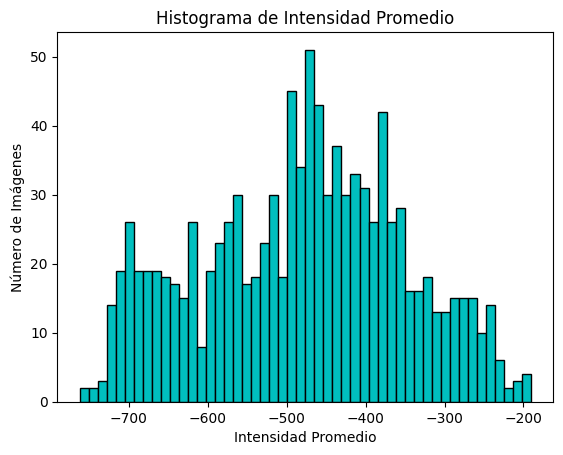

In [19]:
# Se hace saca la intensidad promedio de las iamgenes en los pixeles que son 1 en la máscara
def get_average_intensity(images, masks):
    avg_intensity = []
    for i in tqdm(range(len(images))):
        avg_intensity.append(np.sum(images[i] * masks[i]) / np.sum(masks[i]))
    return avg_intensity

# Se obtiene la intensidad promedio de las imágenes
avg_intensity = get_average_intensity(Xtrain, Ytrain)

# Se muestran los resultados en un histograma
plt.hist(avg_intensity, bins=50, color='c', edgecolor='k')
plt.xlabel('Intensidad Promedio')
plt.ylabel('Número de Imágenes')
plt.title('Histograma de Intensidad Promedio')
plt.show()

#### Proceso de identificación de atípicos

1. Cálculo del rango intercuartil (IQR):

    * Primero, se calcula los percentiles 25 (Q1) y 75 (Q3) de las intensidades promedio.
    * El rango intercuartil (IQR) se calcula como la diferencia entre el tercer y el primer percentil (Q3 - Q1). Es una medida de dispersión que indica cuánto se extienden los datos en la región central de la distribución.

2. Definición de los límites para identificar valores atípicos:

    * Se usa el IQR para definir los límites inferior y superior para identificar los valores atípicos. Estos límites se calculan como Q1 - 1.5 * IQR y Q3 + 1.5 * IQR, respectivamente.
    * Los valores que estén por debajo del límite inferior o por encima del límite superior se consideran valores atípicos.



In [20]:
# Función que recibe una imagen y una mascara y devuelve el histogrmaa de isntensidades de los valores de la imagen que son 1 en la máscara y meustra la imagen
def show_image_histogram(image, mask):
    plt.hist(image[mask > 0].flatten(), bins=50, color='c', edgecolor='k')
    plt.title('Histograma de Intensidades')
    plt.xlabel('Intensidad')
    plt.ylabel('Número de Pixeles')

    plt.show()

100%|██████████| 1027/1027 [00:00<00:00, 15796.28it/s]


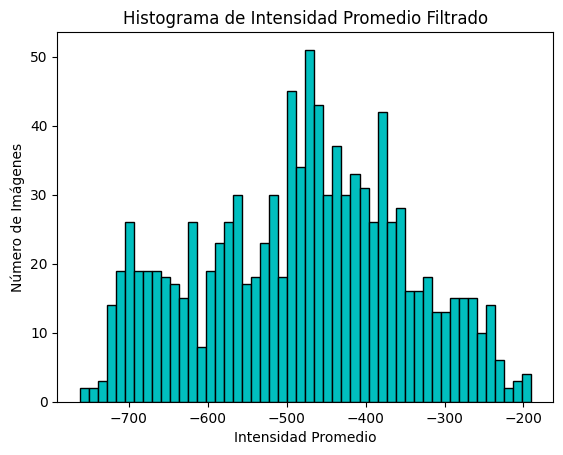

Imágenes de entranamiento filtradas (outliers):  1027
Máscaras de entrenamiento filtradas (outliers):  1027
Intensidad promedio:  -480.54


In [21]:
# Calculo del IQR por medio de los percentiles 25 y 75
Q1 = np.percentile(avg_intensity, 25)
Q3 = np.percentile(avg_intensity, 75)

# Definición de los rangos superior e inferior
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Se filtran los outliers de las imágenes y las máscaras
def remove_outliers(images, masks, avg_intensity, lower_bound, upper_bound):
    images_filtered = []
    masks_filtered = []
    for i in tqdm(range(len(images))):
        if avg_intensity[i] >= lower_bound and avg_intensity[i] <= upper_bound:
            #print("Imagen promedio: ", img_name_train[i])
            #show_image_histogram(images[i], masks[i])
            #show_image_with_mask(images[i], masks[i])
            images_filtered.append(images[i])
            masks_filtered.append(masks[i])
        #else:
            #print("Imagen atípica: ", img_name_train[i])
            #show_image_histogram(images[i], masks[i])
            #show_image_with_mask(images[i], masks[i])
    return images_filtered, masks_filtered

Xtrain, Ytrain = remove_outliers(Xtrain, Ytrain, avg_intensity, lower_bound, upper_bound)

# Visualización del histograma de intensidades promedio filtradas
avg_intensity = get_average_intensity(Xtrain, Ytrain)
plt.hist(avg_intensity, bins=50, color='c', edgecolor='k')
plt.xlabel('Intensidad Promedio')
plt.ylabel('Número de Imágenes')
plt.title('Histograma de Intensidad Promedio Filtrado')
plt.show()

print("Imágenes de entranamiento filtradas (outliers): ", len(Xtrain))
print("Máscaras de entrenamiento filtradas (outliers): ", len(Ytrain))
print("Intensidad promedio: ", round(np.mean(avg_intensity), 2))

### Aumento de datos

In [22]:
# Función para aumentar los datos
def aumentar_datos(image, mask):
     
    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    img_array = np.expand_dims(image, axis=0)
    mask_array = np.expand_dims(mask, axis=0)

    img_gen = datagen.flow(img_array, batch_size=1, seed=42)

    mask_gen = datagen.flow(mask_array, batch_size=1, seed=42)

    img_aug = img_gen.next()[0]
    mask_aug = mask_gen.next()[0]

    return img_aug, mask_aug

In [23]:
# Función para crear los conjuntos de entrenamiento y validación
def crear_conjuntos(x_train, y_train, x_test, y_test):
  
  # Convertir los conjutnos test en arrays
  Xtest = np.array(x_test)
  Ytest = np.array(y_test)

  # Creamos un array vacío para almacenar las imágenes de entrenamiento y sus máscaras aumentadas
  Xtrain = np.zeros((len(x_train)*2, img_size, img_size, 1))
  Ytrain = np.zeros((len(y_train)*2, img_size, img_size, 1))

  # Contador para asegurar el correcto cargado de imagenes y su augmentation
  idx_aumentado = 0

  for i in tqdm(range(len(x_train))):

    # Sacamos los items del dataset
    im = x_train[i]
    ms = y_train[i]
    ms = (ms > 0).astype(float)

    im_aug, ms_aug = aumentar_datos(im, ms)
    ms_aug = (ms_aug > 0).astype(float)

    Xtrain[idx_aumentado] = im
    Ytrain[idx_aumentado] = ms

    Xtrain[idx_aumentado + 1] = im_aug
    Ytrain[idx_aumentado + 1] = ms_aug

    # Se aumenta idx para controlar la carrecta asignación de espacio
    idx_aumentado += 2
  
  return Xtrain, Ytrain, Xtest, Ytest

In [24]:
# Dividir datos en conjuntos de entrenamiento, validación y prueba
Xtrain, Ytrain, Xtest, Ytest = crear_conjuntos(Xtrain, Ytrain, Xtest, Ytest)

print("Conjunto de entrenamiento - Xtrain:", Xtrain.shape)
print("Conjunto de entrenamiento - Ytrain:", Ytrain.shape)
print("Conjunto de prueba - Xtest:", Xtest.shape)
print("Conjunto de prueba - Ytest:", Ytest.shape)

  0%|          | 0/1027 [00:00<?, ?it/s]

100%|██████████| 1027/1027 [00:01<00:00, 550.25it/s]

Conjunto de entrenamiento - Xtrain: (2054, 128, 128, 1)
Conjunto de entrenamiento - Ytrain: (2054, 128, 128, 1)
Conjunto de prueba - Xtest: (257, 128, 128, 1)
Conjunto de prueba - Ytest: (257, 128, 128, 1)


# Model Definition

In [25]:
from tensorflow.keras import layers
from tensorflow import keras
from tensorflow.keras import backend as K

img_size = (128, 128)
num_classes = 2

## R2 U-Net

In [ ]:
def bloque_doble_conv(capa, filtros):
    capa = tf.keras.layers.Conv2D(filtros, (3,3), kernel_initializer='he_normal', padding='same')(capa)
    capa = tf.keras.layers.LeakyReLU(alpha=0.1)(capa)
    capa = tf.keras.layers.BatchNormalization()(capa)
    capa = tf.keras.layers.Conv2D(filtros, (3,3), kernel_initializer='he_normal', padding='same')(capa)
    capa = tf.keras.layers.BatchNormalization()(capa)
    capa = tf.keras.layers.LeakyReLU(alpha=0.1)(capa)
    return capa

In [ ]:

def rec_res_block(input_tensor, n_filters, batch_normalization=True, kernel_size=(3, 3), data_format='channels_last', weight_decay=1e-4):
    # Inicializa la capa 'skip' para la conexión residual.
    skip_tensor = input_tensor
    if data_format == 'channels_first':
        input_n_filters = input_tensor.shape[1]
    else:
        input_n_filters = input_tensor.shape[-1]

    # Si el número de filtros no coincide, adapta el tensor de entrada.
    if n_filters != input_n_filters:
        skip_tensor = tf.keras.layers.Conv2D(n_filters, (1, 1), padding='same',kernel_regularizer=tf.keras.regularizers.l2(weight_decay))(input_tensor)
        if batch_normalization:
            skip_tensor = tf.keras.layers.BatchNormalization()(skip_tensor)

    for i in range(2): 
        # Aplica bloques de convolución.
        conv_tensor = tf.keras.layers.Conv2D(n_filters, kernel_size, activation=None, padding='same',kernel_regularizer=tf.keras.regularizers.l2(weight_decay))(skip_tensor)
        if batch_normalization:
            conv_tensor = tf.keras.layers.BatchNormalization()(conv_tensor)
        conv_tensor = tf.keras.layers.LeakyReLU(alpha=0.2)(conv_tensor)

        # Suma la entrada con la salida (conexión residual).
        skip_tensor = tf.keras.layers.Add()([conv_tensor, skip_tensor])
    
    # Devuelve la suma del último tensor de salida con el tensor de salto (skip_tensor).
    if batch_normalization:
        skip_tensor = tf.keras.layers.BatchNormalization()(skip_tensor)
    skip_tensor = tf.keras.layers.LeakyReLU(alpha=0.2)(skip_tensor)

    return skip_tensor

def bloque_downsampling(input_tensor, n_filters):
    features = rec_res_block(input_tensor, n_filters)
    pooled_features = tf.keras.layers.MaxPooling2D((2,2))(features)
    pooled_features = tf.keras.layers.Dropout(0.3)(pooled_features)
    return features, pooled_features

def bloque_upsampling(input_tensor, skip_features, n_filters):
    upsampled = tf.keras.layers.Conv2DTranspose(n_filters, (3, 3), strides=(2, 2), padding='same')(input_tensor)
    merged = tf.keras.layers.concatenate([upsampled, skip_features])
    capa = rec_res_block(merged, n_filters)
    capa = tf.keras.layers.Dropout(0.3)(capa)
    return capa

In [ ]:
def get_model(img_size, num_classes):

  inputs = keras.Input(shape=img_size + (1,))

  ### Parte decendente de la red ###

  f1, c1 = bloque_downsampling(inputs, 32)
  f2, c2 = bloque_downsampling(c1, 64)
  f3, c3 = bloque_downsampling(c2, 128)
  f4, c4 = bloque_downsampling(c3, 256)
  ### Fondo de la red

  c5 = bloque_doble_conv(c4, 512)

  ### Parte ascendente de la red

  c6 = bloque_upsampling(c5, f4, 256)
  c7 = bloque_upsampling(c6, f3, 128)
  c8 = bloque_upsampling(c7, f2, 64)
  c9 = bloque_upsampling(c8, f1, 32)

  ### Capa de salida
  outputs = layers.Conv2D(num_classes, 3, activation='softmax', padding='same')(c9)


  # Definición del modelo
  model = keras.Model(inputs, outputs)
  return model

In [ ]:
# Liberamos espacio en la RAM
keras.backend.clear_session()

# Resumamos el modelo
model = get_model(img_size=img_size, num_classes=2)
model.summary()

## Att U-Net

In [ ]:
def bloque_doble_conv(capa, filtros):
    capa = tf.keras.layers.Conv2D(filtros, (3,3), kernel_initializer='he_normal', padding='same')(capa)
    capa = tf.keras.layers.LeakyReLU(alpha=0.1)(capa)
    capa = tf.keras.layers.BatchNormalization()(capa)
    capa = tf.keras.layers.Conv2D(filtros, (3,3), kernel_initializer='he_normal', padding='same')(capa)
    capa = tf.keras.layers.BatchNormalization()(capa)
    capa = tf.keras.layers.LeakyReLU(alpha=0.1)(capa)
    return capa

def expend_as(tensor, rep):
     return layers.Lambda(lambda x, repnum: K.repeat_elements(x, repnum, axis=3),
                          arguments={'repnum': rep})(tensor)


def gating_signal(input_tensor, out_size, batch_norm=False):
    gate = tf.keras.layers.Conv2D(out_size, (2, 2), padding='same')(input_tensor)
    if batch_norm:
        gate = tf.keras.layers.BatchNormalization()(gate)
    gate = tf.keras.layers.LeakyReLU(alpha=0.1)(gate)
    return gate

def attention_block(x, gating, inter_shape):

    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

    theta_x = tf.keras.layers.Conv2D(inter_shape, (2, 2), strides=(2, 2), padding='same')(x)
    shape_theta_x = K.int_shape(theta_x)

    phi_g = tf.keras.layers.Conv2D(inter_shape, (1, 1), padding='same')(gating)
    upsample_g = tf.keras.layers.Conv2DTranspose(inter_shape, (3, 3),
                                            strides=(shape_theta_x[1] // shape_g[1], shape_theta_x[2] // shape_g[2]),
                                            padding='same')(phi_g)

    concat_xg = tf.keras.layers.add([upsample_g, theta_x])
    act_xg  = tf.keras.layers.LeakyReLU(alpha=0.1)(concat_xg)
    psi = tf.keras.layers.Conv2D(1, (1, 1), padding='same')(act_xg)
    sigmoid_xg = tf.keras.layers.Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)

    upsample_psi = tf.keras.layers.UpSampling2D(size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)
    upsample_psi = expend_as(upsample_psi, shape_x[3])

    y = tf.keras.layers.Multiply()([upsample_psi, x])

    result = tf.keras.layers.Conv2D(shape_x[3], (1, 1), padding='same')(y)
    result_bn = tf.keras.layers.BatchNormalization()(result)
    return result_bn

def bloque_upsampling(capa, features, filtros):
    gating_feature = gating_signal(capa, filtros // 2, batch_norm=True)
    attention_features = attention_block(features, gating_feature, filtros // 2)
    upsampled = tf.keras.layers.Conv2DTranspose(filtros, (3, 3), strides=(2, 2), padding='same')(capa)
    merged = tf.keras.layers.concatenate([upsampled, attention_features])
    final = bloque_doble_conv(merged, filtros)
    return final

In [ ]:
def bloque_downsampling(capa, filtros):
   #features = bloque_residual(capa, filtros)
   features = bloque_doble_conv(capa, filtros)
   capa = tf.keras.layers.MaxPool2D((2,2))(features)
   capa = tf.keras.layers.Dropout(0.3) (capa)
   return features, capa

In [ ]:
def get_model(img_size, num_classes):

  inputs = keras.Input(shape=img_size + (1,))

  ### Parte decendente de la red ###

  f1, c1 = bloque_downsampling(inputs, 32)
  f2, c2 = bloque_downsampling(c1, 64)
  f3, c3 = bloque_downsampling(c2, 128)
  f4, c4 = bloque_downsampling(c3, 256)
  ### Fondo de la red

  c5 = bloque_doble_conv(c4, 512)

  ### Parte ascendente de la red

  c6 = bloque_upsampling(c5, f4, 256)
  c7 = bloque_upsampling(c6, f3, 128)
  c8 = bloque_upsampling(c7, f2, 64)
  c9 = bloque_upsampling(c8, f1, 32)

  ### Capa de salida
  outputs = tf.keras.layers.Conv2D(num_classes, 3, activation='softmax', padding='same')(c9)


  # Definición del modelo
  model = keras.Model(inputs, outputs)
  return model

In [ ]:
# Liberamos espacio en la RAM
keras.backend.clear_session()

# Resumamos el modelo
model = get_model(img_size=img_size, num_classes=2)
model.summary()

In [ ]:
def bloque_doble_conv(capa, filtros):
    capa = tf.keras.layers.Conv2D(filtros, (3,3), kernel_initializer='he_normal', padding='same')(capa)
    capa = tf.keras.layers.LeakyReLU(alpha=0.1)(capa)
    capa = tf.keras.layers.BatchNormalization()(capa)
    capa = tf.keras.layers.Conv2D(filtros, (3,3), kernel_initializer='he_normal', padding='same')(capa)
    capa = tf.keras.layers.BatchNormalization()(capa)
    capa = tf.keras.layers.LeakyReLU(alpha=0.1)(capa)
    return capa

In [ ]:
def rec_res_block(input_tensor, n_filters, batch_normalization=True, kernel_size=(3, 3), data_format='channels_last'):
    # Inicializa la capa 'skip' para la conexión residual.
    skip_tensor = input_tensor
    if data_format == 'channels_first':
        input_n_filters = input_tensor.shape[1]
    else:
        input_n_filters = input_tensor.shape[-1]

    # Si el número de filtros no coincide, adapta el tensor de entrada.
    if n_filters != input_n_filters:
        skip_tensor = tf.keras.layers.Conv2D(n_filters, (1, 1), padding='same')(input_tensor)
        if batch_normalization:
            skip_tensor = tf.keras.layers.BatchNormalization()(skip_tensor)

    for i in range(2): 
        # Aplica bloques de convolución.
        conv_tensor = tf.keras.layers.Conv2D(n_filters, kernel_size, activation=None, padding='same')(skip_tensor)
        if batch_normalization:
            conv_tensor = tf.keras.layers.BatchNormalization()(conv_tensor)
        conv_tensor = tf.keras.layers.LeakyReLU(alpha=0.2)(conv_tensor)

        # Suma la entrada con la salida (conexión residual).
        skip_tensor = tf.keras.layers.Add()([conv_tensor, skip_tensor])
    
    # Devuelve la suma del último tensor de salida con el tensor de salto (skip_tensor).
    if batch_normalization:
        skip_tensor = tf.keras.layers.BatchNormalization()(skip_tensor)
    skip_tensor = tf.keras.layers.LeakyReLU(alpha=0.2)(skip_tensor)

    return skip_tensor


def bloque_downsampling(input_tensor, n_filters):
    features = rec_res_block(input_tensor, n_filters)
    pooled_features = tf.keras.layers.MaxPooling2D((2,2))(features)
    pooled_features = tf.keras.layers.Dropout(0.3)(pooled_features)
    return features, pooled_features

def bloque_upsampling(input_tensor, skip_features, n_filters):
    upsampled = tf.keras.layers.Conv2DTranspose(n_filters, (3, 3), strides=(2, 2), padding='same')(input_tensor)
    merged = tf.keras.layers.concatenate([upsampled, skip_features])
    capa = rec_res_block(merged, n_filters)
    capa = tf.keras.layers.Dropout(0.3)(capa)
    return capa

In [ ]:
def get_model(img_size, num_classes):

  inputs = keras.Input(shape=img_size + (1,))

  ### Parte decendente de la red ###

  f1, c1 = bloque_downsampling(inputs, 32)
  f2, c2 = bloque_downsampling(c1, 64)
  f3, c3 = bloque_downsampling(c2, 128)
  f4, c4 = bloque_downsampling(c3, 256)
  ### Fondo de la red

  c5 = bloque_doble_conv(c4, 512)

  ### Parte ascendente de la red

  c6 = bloque_upsampling(c5, f4, 256)
  c7 = bloque_upsampling(c6, f3, 128)
  c8 = bloque_upsampling(c7, f2, 64)
  c9 = bloque_upsampling(c8, f1, 32)

  ### Capa de salida
  outputs = layers.Conv2D(num_classes, 3, activation='softmax', padding='same')(c9)


  # Definición del modelo
  model = keras.Model(inputs, outputs)
  return model

In [ ]:
# Liberamos espacio en la RAM
keras.backend.clear_session()

# Resumamos el modelo
model = get_model(img_size=img_size, num_classes=2)
model.summary()

## Att R2 UNET

### Bloque de atención

In [ ]:
def bloque_doble_conv(capa, filtros):
    capa = tf.keras.layers.Conv2D(filtros, (3,3), kernel_initializer='he_normal', padding='same')(capa)
    capa = tf.keras.layers.LeakyReLU(alpha=0.2)(capa)
    capa = tf.keras.layers.BatchNormalization()(capa)
    capa = tf.keras.layers.Conv2D(filtros, (3,3), kernel_initializer='he_normal', padding='same')(capa)
    capa = tf.keras.layers.BatchNormalization()(capa)
    capa = tf.keras.layers.LeakyReLU(alpha=0.2)(capa)
    return capa

def expend_as(tensor, rep):
    return layers.Lambda(lambda x, repnum: K.repeat_elements(x, repnum, axis=3),
                         arguments={'repnum': rep})(tensor)

def gating_signal(input_tensor, out_size, batch_norm=False):
    gate = tf.keras.layers.Conv2D(out_size, (2, 2), padding='same')(input_tensor)
    if batch_norm:
        gate = tf.keras.layers.BatchNormalization()(gate)
    gate = tf.keras.layers.LeakyReLU(alpha=0.2)(gate)
    return gate

def attention_block(x, gating, inter_shape):

    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

    theta_x = tf.keras.layers.Conv2D(inter_shape, (2, 2), strides=(2, 2), padding='same')(x)
    shape_theta_x = K.int_shape(theta_x)

    phi_g = tf.keras.layers.Conv2D(inter_shape, (1, 1), padding='same')(gating)
    upsample_g = tf.keras.layers.Conv2DTranspose(inter_shape, (3, 3),
                                            strides=(shape_theta_x[1] // shape_g[1], shape_theta_x[2] // shape_g[2]),
                                            padding='same')(phi_g)

    concat_xg = tf.keras.layers.add([upsample_g, theta_x])
    act_xg  = tf.keras.layers.LeakyReLU(alpha=0.2)(concat_xg)
    psi = tf.keras.layers.Conv2D(1, (1, 1), padding='same')(act_xg)
    sigmoid_xg = tf.keras.layers.Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)

    upsample_psi = tf.keras.layers.UpSampling2D(size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)
    upsample_psi = expend_as(upsample_psi, shape_x[3])

    y = tf.keras.layers.Multiply()([upsample_psi, x])

    result = tf.keras.layers.Conv2D(shape_x[3], (1, 1), padding='same')(y)
    result_bn = tf.keras.layers.BatchNormalization()(result)
    return result_bn

### Bloque residual concurrente


In [ ]:
def rec_res_block(input_tensor, n_filters, batch_normalization=False, kernel_size=(3, 3)):
    # Inicializa la capa 'skip' para la conexión residual.
    skip_tensor = input_tensor
    input_n_filters = input_tensor.shape[-1]

    # Si el número de filtros no coincide, adapta el tensor de entrada.
    if n_filters != input_n_filters:
        skip_tensor = tf.keras.layers.Conv2D(n_filters, (1, 1), padding='same')(input_tensor)
        if batch_normalization:
            skip_tensor = tf.keras.layers.BatchNormalization()(skip_tensor)

    for i in range(2): 
        # Aplica bloques de convolución.
        conv_tensor = tf.keras.layers.Conv2D(n_filters, kernel_size, activation=None, padding='same')(skip_tensor)
        if batch_normalization:
            conv_tensor = tf.keras.layers.BatchNormalization()(conv_tensor)
        conv_tensor = tf.keras.layers.LeakyReLU(alpha=0.2)(conv_tensor)

        # Suma la entrada con la salida (conexión residual).
        skip_tensor = tf.keras.layers.Add()([conv_tensor, skip_tensor])
    
    # Devuelve la suma del último tensor de salida con el tensor de salto (skip_tensor).
    if batch_normalization:
        skip_tensor = tf.keras.layers.BatchNormalization()(skip_tensor)
    skip_tensor = tf.keras.layers.LeakyReLU(alpha=0.2)(skip_tensor)

    return skip_tensor

### Subredes

In [ ]:
def att_r2_downsampling(input_tensor, n_filters):
    features = rec_res_block(input_tensor, n_filters)
    pooled_features = tf.keras.layers.MaxPooling2D((2,2))(features)
    pooled_features = tf.keras.layers.Dropout(0.3)(pooled_features)
    return features, pooled_features

def att_r2_upsampling(input_tensor, skip_features, n_filters):
    gatting_feature = gating_signal(input_tensor, n_filters // 2, batch_norm=True)
    attention_features = attention_block(skip_features, gatting_feature, n_filters // 2)
    upsampled = tf.keras.layers.Conv2DTranspose(n_filters, (3, 3), strides=(2, 2), padding='same')(input_tensor)
    merged = tf.keras.layers.concatenate([upsampled, attention_features])
    final = rec_res_block(merged, n_filters)
    final = tf.keras.layers.Dropout(0.3)(final)
    return final

### Creación del modelo

In [ ]:
def get_model(img_size, num_classes):
    inputs = tf.keras.Input(shape=img_size + (1,))
    
    ### Parte descendente de la red ###
    f1, c1 = att_r2_downsampling(inputs, 32)
    f2, c2 = att_r2_downsampling(c1, 64)
    f3, c3 = att_r2_downsampling(c2, 128)
    f4, c4 = att_r2_downsampling(c3, 256)
    
    ### Fondo de la red ###
    c5 = bloque_doble_conv(c4, 512)
    
    ### Parte ascendente de la red ###
    c6 = att_r2_upsampling(c5, f4, 256)
    c7 = att_r2_upsampling(c6, f3, 128)
    c8 = att_r2_upsampling(c7, f2, 64)
    c9 = att_r2_upsampling(c8, f1, 32)
    
    ### Capa de salida ###
    outputs = tf.keras.layers.Conv2D(num_classes, (1, 1), activation='softmax')(c9)
    
    # Definición del modelo
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    return model

# Ejemplo de uso
model = get_model(img_size, num_classes=2)
model.summary()

## Modelo base

In [ ]:
def bloque_residual(capa, filtros):
    shortcut = capa
    capa = tf.keras.layers.Conv2D(filtros, (3,3), activation='relu', kernel_initializer='he_normal', padding='same') (capa)
    capa = tf.keras.layers.Conv2D(filtros, (3,3), activation='relu', kernel_initializer='he_normal', padding='same') (capa)

    capa = tf.keras.layers.concatenate([shortcut, capa])
    return capa


#def bloque_doble_conv(capa, filtros):
#   capa = tf.keras.layers.Conv2D(filtros, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(capa)
#   capa = tf.keras.layers.Conv2D(filtros, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(capa)
#   return capa

def bloque_doble_conv(capa, filtros, activation='relu'):
    capa = tf.keras.layers.Conv2D(filtros, (3,3), kernel_initializer='he_normal', padding='same')(capa)
    if activation == 'relu':
        capa = tf.keras.layers.Activation('relu')(capa)
    elif activation == 'leakyrelu':
        capa = tf.keras.layers.LeakyReLU(alpha=0.1)(capa)
    elif activation == 'sigmoid':
        capa = tf.keras.layers.Activation('sigmoid')(capa)
    elif activation == 'PReLU':
        capa = tf.keras.layers.PReLU()(capa)

    capa = tf.keras.layers.BatchNormalization()(capa)
    capa = tf.keras.layers.Conv2D(filtros, (3,3), kernel_initializer='he_normal', padding='same')(capa)
    capa = tf.keras.layers.BatchNormalization()(capa)

    if activation == 'relu':
        capa = tf.keras.layers.Activation('relu')(capa)
    elif activation == 'leakyrelu':
        capa = tf.keras.layers.LeakyReLU(alpha=0.1)(capa)
    elif activation == 'sigmoid':
        capa = tf.keras.layers.Activation('sigmoid')(capa)
    elif activation == 'PReLU':
        capa = tf.keras.layers.PReLU()(capa)
    return capa


In [ ]:
def bloque_downsampling(capa, filtros):
   #features = bloque_residual(capa, filtros)
   features = bloque_doble_conv(capa, filtros, 'leakyrelu')
   capa = tf.keras.layers.MaxPool2D((2,2))(features)
   capa = tf.keras.layers.Dropout(0.3) (capa)
   return features, capa

def bloque_upsampling(capa, features, filtros ):
    capa = tf.keras.layers.Conv2DTranspose(filtros, 3, 2, padding='same') (capa)
    capa = tf.keras.layers.concatenate([capa, features])
    capa = tf.keras.layers.Dropout(0.3) (capa)
    #capa = bloque_residual(capa, filtros)
    capa = bloque_doble_conv(capa, filtros, 'leakyrelu')
    return capa

In [ ]:
def get_model(img_size, num_classes):

  inputs = keras.Input(shape=img_size + (1,))

  ### Parte decendente de la red ###

  f1, c1 = bloque_downsampling(inputs, 32)
  f2, c2 = bloque_downsampling(c1, 64)
  f3, c3 = bloque_downsampling(c2, 128)
  f4, c4 = bloque_downsampling(c3, 256)
  ### Fondo de la red

  c5 = bloque_doble_conv(c4, 512)

  ### Parte ascendente de la red

  c6 = bloque_upsampling(c5, f4, 256)
  c7 = bloque_upsampling(c6, f3, 128)
  c8 = bloque_upsampling(c7, f2, 64)
  c9 = bloque_upsampling(c8, f1, 32)

  ### Capa de salida
  outputs = layers.Conv2D(num_classes, 3, activation='softmax', padding='same')(c9)


  # Definición del modelo
  model = keras.Model(inputs, outputs)
  return model

In [ ]:
# Liberamos espacio en la RAM
keras.backend.clear_session()

# Resumamos el modelo
model = get_model(img_size=img_size, num_classes=2)
model.summary()

# Training

In [ ]:
model.compile(optimizer="rmsprop", loss= "sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
#earlyStopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
#model.fit(Xtrain, Ytrain, validation_data=(Xtest, Ytest), batch_size=8, epochs=20, callbacks=[earlyStopping])

model.fit(Xtrain, Ytrain, validation_data=(Xtest, Ytest), batch_size=8, epochs=20)

In [ ]:
model.save(data_path+'/modelos/mo_r2_coronacases.keras')

# Evaluation

In [26]:
model = load_model(data_path+'/modelos/mo_r2_zenodo_data2.keras')

## Métricas


In [27]:
from sklearn.metrics import confusion_matrix,precision_score, recall_score, roc_auc_score # type: ignore

def dice_coefficient(image1, image2):
    intersection = np.logical_and(image1, image2)
    intersection_sum = np.sum(intersection)
    image1_sum = np.sum(image1)
    image2_sum = np.sum(image2)

    if (image1_sum + image2_sum) == 0:
        dice = 0
    else:
        dice = (2.0 * intersection_sum) / (image1_sum + image2_sum)

    return dice

def indice_IoU(image1, image2):
    image1 = image1.flatten()
    image2 = image2.flatten()

    interseccion = np.sum((image1 == 1) & (image2 == 1))
    union = np.sum((image1 == 1) | (image2 == 1))

    if union == 0:
        return 0.0

    iou = interseccion / union
    return iou

## Función de predicción

In [28]:
def binarizar_probabilidad(prob_mask, umbral=0.3):
    msk_pred = np.expand_dims(prob_mask[0, :, :, 1], axis=-1)
    msk_pred = (msk_pred > umbral).astype(int)
    return msk_pred

def predecir_imagen(model, n_img, xdata, umbral=0.3):
    img = np.expand_dims(xdata[n_img], axis=0)
    prob_mask = model.predict(img)
    msk_pred = binarizar_probabilidad(prob_mask, umbral)
    return msk_pred

def mostrar_prediccion(model, n_img, xdata, ydata, umbral=0.3):
    img = np.expand_dims(xdata[n_img], axis=0)
    prob_mask = model.predict(img)
    msk_pred = binarizar_probabilidad(prob_mask, umbral)
    img_true = ydata[n_img]
    img = np.squeeze(img, axis=0)
    show_image_masks(img, img_true, msk_pred)

1/1 [==============================] - 4s 4s/step


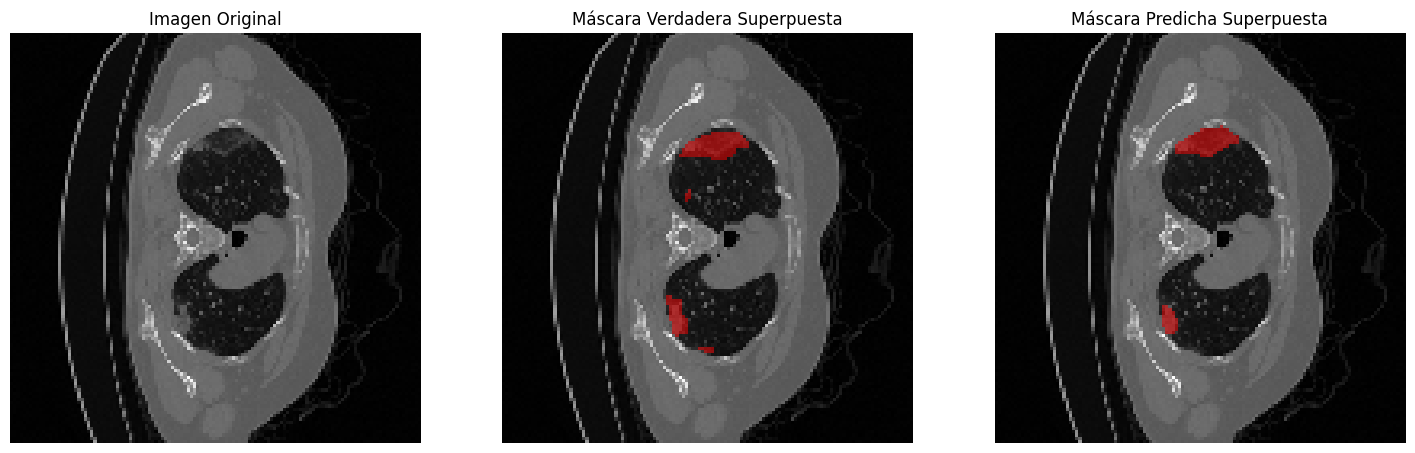

In [29]:
# Visualización de la predicción de una imagen de prueba
mostrar_prediccion(model, 0, Xtest, Ytest, 0.3)

## Validación cualitativa

In [30]:
# Función para evaluar el modelo en el conjunto de prueba
def score_test(x_test, y_test, model):
    total = len(x_test)
    dc_score = 0
    iou_total = 0
    recall_total = 0
    prec_total = 0
    auc_total = 0
    confusion_matrices = []

    for i in range(total):
        img = np.expand_dims(x_test[i], axis=0)
        segm = model.predict(img)
        img_pred = binarizar_probabilidad(segm)
        img_true = y_test[i]

        # Calculando el coeficiente Dice e indice IoU
        dc_score += dice_coefficient(img_true, img_pred)
        iou_total += indice_IoU(img_true, img_pred)

        # Aplanar las imágenes para usar en las métricas
        img_true_labels = img_true[:, :, 0].flatten()
        img_pred_labels = img_pred[:, :, 0].flatten()

        # Calcular el AUC solo si hay etiquetas verdaderas
        if np.any(img_true_labels):
            auc_total += roc_auc_score(img_true_labels, img_pred_labels)
            confusion_matrices.append(confusion_matrix(img_true_labels, img_pred_labels))

        # Calcular Recall y Precisión
        recall_total += recall_score(img_true_labels, img_pred_labels, zero_division=0)
        prec_total += precision_score(img_true_labels, img_pred_labels, zero_division=0)
        

    # Calcular promedios para las métricas
    dice_avg = round((dc_score / total), 3)
    iou_avg = round((iou_total / total), 3)
    r_avg = round((recall_total / total), 3)
    p_avg = round((prec_total / total), 3)
    auc_avg = round((auc_total / total), 3)

    # Calcular la matriz de confusión promedio
    avg_confusion_matrix = np.mean(confusion_matrices, axis=0)

    # Mostrar los resultados finales
    result = f"Coeficiente de Dice promedio: {dice_avg}, IoU promedio: {iou_avg}, Puntaje de recall promedio: {r_avg}, Puntaje de precisión promedio: {p_avg}, AUC promedio: {auc_avg}"
    result += " Matriz de confusión promedio: "
    result += str(avg_confusion_matrix)

    return result

In [31]:
def score_masks(msk_true, msk_pred):
    dc_score = dice_coefficient(msk_true, msk_pred)
    img_true_labels = msk_true[:, :, 0].flatten()
    img_pred_labels = msk_pred[:, :, 0].flatten()
    IoU = indice_IoU(msk_true, msk_pred)
    recall = recall_score(img_true_labels, img_pred_labels, zero_division=0)
    prec = precision_score(img_true_labels, img_pred_labels, zero_division=0)
    auc = roc_auc_score(img_true_labels, img_pred_labels)

    # Respuesta a string
    result = f"Coeficiente de Dice: {round(dc_score, 2)}, IoU: {round(IoU, 2)}, Recall: {round(recall, 2)}, Precisión: {round(prec, 2)}, AUC: {round(auc, 2)}"

    return result, dc_score

In [32]:
score_test(Xtest,Ytest, model)

1/1 [==============================] - 0s 19ms/step


'Coeficiente de Dice promedio: 0.703, IoU promedio: 0.58, Puntaje de recall promedio: 0.691, Puntaje de precisión promedio: 0.776, AUC promedio: 0.845 Matriz de confusión promedio: [[16122.78599222    37.0311284 ]\n [   50.19844358   173.9844358 ]]'

## Exploración método tradicional


In [ ]:
from skimage.measure import label, regionprops
from skimage.morphology import dilation, erosion, square

In [ ]:
def compare_imgs(img_bef, img_aft):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img_bef, cmap='gray')
    axes[0].set_title('Imagen Original')
    axes[0].axis('off')
    axes[1].imshow(img_aft, cmap='gray')
    axes[1].set_title('Imagen Modificada')
    axes[1].axis('off')
    plt.show()

In [ ]:
img_pred = predecir_imagen(model, 0, Xtest, umbral=0.3)
img_np = img_pred.flatten()
img_true_np = Ytest[0].flatten()
score_test(img_np, img_true_np, model)

### 1. Dilatación y erosión

In [ ]:
dilated_img = dilation(np.squeeze(img_pred), square(5))
compare_imgs(np.squeeze(img_pred), dilated_img)

In [ ]:
eroded_img = erosion(np.squeeze(img_pred), square(2))
compare_imgs(dilated_img, eroded_img)

* Por ahora con el ejemplo implementado la erosión no es una opción posteriormente se hará uan evaluación del resndimiento con y sin el 

### 2. Bounding boxes y centroides

In [ ]:
dilated_img = np.squeeze(dilated_img)

In [ ]:
labaled_img = label(dilated_img)
regions = regionprops(labaled_img)

seeds = []
bbox = []

for region in regions:

    # Bounding Box
    minr, minc, maxr, maxc = region.bbox
    bbox.append((minr, minc, maxr, maxc))

    # Centroid
    cy, cx = region.centroid

    # Agregar las semillas a la lista
    seeds.append((int(cx), int(cy)))

In [ ]:
def show_bbox(image, bboxes, seeds):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(image, cmap='gray')
    for bbox in bboxes:
        minr, minc, maxr, maxc = bbox
        rect = plt.Rectangle((minc, minr), maxc - minc, maxr - minr, fill=False, edgecolor='red', linewidth=1)
        ax.add_patch(rect)
    for seed in seeds:
        ax.plot(seed[0], seed[1], 'ro', markersize=1)
    plt.show()

In [ ]:
show_bbox(dilated_img, bbox, seeds)

In [ ]:
def region_growing_with_bounds(img, seeds, bboxes, threshold):
    # Aplicamos un filtro gaussiano a la imagen
    img = cv2.GaussianBlur(img, (3, 3), 0)

    img = cv2.adaptiveThreshold(img, 255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY, 11, 2)

    plt.imshow(img, cmap='gray')

    # Calcular el gradiente de la imagen
    grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    grad_magnitude = np.sqrt(grad_x ** 2 + grad_y ** 2)


    # Imagen para marcar las regiones crecidas
    output = np.zeros_like(img, dtype=np.uint8)

    # Procesar cada semilla con su bounding box correspondiente
    for (seed, bbox) in zip(seeds, bboxes):
        minr, minc, maxr, maxc = bbox
        region_queue = [seed]
        output[seed[1], seed[0]] = 255 

        while region_queue:
            x, y = region_queue.pop(0)
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    nx, ny = x + dx, y + dy
                    if minc <= nx < maxc and minr <= ny < maxr: 
                        if output[ny, nx] == 0 and grad_magnitude[ny, nx] < threshold:
                            output[ny, nx] = 1
                            region_queue.append((nx, ny))

    return output, grad_magnitude

def region_growing_with_active_contours(img, seeds, bboxes, contornos_activos, threshold):
    # Imagen de salida vacía
    output = np.zeros_like(img, dtype=np.uint8)
    mask_bboxes = np.zeros_like(img, dtype=np.uint8)

    # Iterar sobre cada bounding box con las semillas
    for seed, bbox, snake in zip(seeds, bboxes, contornos_activos):
        minr, minc, maxr, maxc = bbox

        # Máscara basada en el contorno activo de cada bbox
        mask_bbox = np.zeros_like(img, dtype=np.uint8)
        snake_indices = np.round(snake).astype(int)
        snake_indices = snake_indices[(minr <= snake_indices[:, 0]) & (snake_indices[:, 0] < maxr) &
                                      (minc <= snake_indices[:, 1]) & (snake_indices[:, 1] < maxc)]
        mask_bbox[snake_indices[:, 0], snake_indices[:, 1]] = 1

        # Expandir el contorno con operaciones morfológicas para suavizar la máscara
        kernel = np.ones((3, 3), np.uint8)
        mask_bbox = cv2.dilate(mask_bbox, kernel, iterations=1)
        mask_bboxes = mask_bboxes + mask_bbox

        # Verificar que la semilla esté dentro del contorno activo
        if not (minc <= seed[0] < maxc and minr <= seed[1] < maxr) or mask_bbox[seed[1], seed[0]] == 0:
            continue

        # Crecimiento desde la semilla
        region_queue = [seed]
        output[seed[1], seed[0]] = 255
        while region_queue:
            x, y = region_queue.pop(0)
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    nx, ny = x + dx, y + dy
                    if minc <= nx < maxc and minr <= ny < maxr and mask_bbox[ny, nx] == 1:
                        if output[ny, nx] == 0 and abs(img[ny, nx] - img[y, x]) < threshold:
                            output[ny, nx] = 255
                            region_queue.append((nx, ny))

    return output, mask_bboxes

def region_growing_using_histograms(img, seeds, bboxes, treshold):

    # Imagen para marcar las regiones crecidas
    output = np.zeros_like(img, dtype=np.uint8)

    # Procesar cada semilla con su bounding box correspondiente
    for (seed, bbox) in zip(seeds, bboxes):
        minr, minc, maxr, maxc = bbox
        region_queue = [seed]
        output[seed[1], seed[0]] = 255

        while region_queue:
            x, y = region_queue.pop(0)
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    nx, ny = x + dx, y + dy
                    if minc <= nx < maxc and minr <= ny < maxr:
                        hist1 = cv2.calcHist([img[y-1:y+1, x-1:x+1]], [0], None, [256], [0, 256])
                        hist2 = cv2.calcHist([img[ny-1:ny+1, nx-1:nx+1]], [0], None, [256], [0, 256])
                        similarity = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
                        if output[ny, nx] == 0 and similarity > treshold:
                            output[ny, nx] = 255
                            region_queue.append((nx, ny))

    return output

In [ ]:
# Función modificada para visualizar contornos activos
def mask_active_contours(img, bboxes, contornos_activos):

    #copia de la imagen 
    img_viz = img.copy()

    # Iterar sobre cada bounding box 
    for bbox, snake in zip(bboxes, contornos_activos):
        minr, minc, maxr, maxc = bbox

        snake_indices = np.round(snake).astype(int)
        snake_indices = snake_indices[(minr <= snake_indices[:, 0]) & (snake_indices[:, 0] < maxr) &
                                      (minc <= snake_indices[:, 1]) & (snake_indices[:, 1] < maxc)]

        # Dibujar el contorno activos
        for coord in snake_indices:
            img_viz[coord[0], coord[1]] = 255  

    return img_viz

In [ ]:
from skimage.filters import gaussian
from skimage.segmentation import active_contour

def obtener_contorno_activo(img, bboxes, alpha=0.015, beta=10, gamma=0.001):
    contornos_list = []
    imgs_limited = []
    init_list = []
    for bbox in bboxes:
        minr, minc, maxr, maxc = bbox
        img_limited = img[minr:maxr, minc:maxc]
        imgs_limited.append(img_limited)

        # Convertir la bbox en un np.array en forma de circulo
        s = np.linspace(0, 2 * np.pi, 100)
        r = (maxr - minr) // 2
        c = (maxc - minc) // 2
        init = np.array([r + r * np.cos(s), c + c * np.sin(s)]).T
        init_list.append(init) 

        snake = active_contour(gaussian(img_limited, sigma=1, preserve_range=False),init, alpha=alpha, beta=beta, gamma=gamma)
        
        snake[:, 0] += minr
        snake[:, 1] += minc

        # Añadir a la lista
        contornos_list.append(snake)
    
    # Visualizar las imagenes limitadas
    for img_lim in imgs_limited:
        plt.figure(figsize=(5, 5))
        plt.imshow(gaussian(img_lim, sigma=1, preserve_range=False), cmap='gray')
        plt.axis('off')
        plt.show()
    
    return contornos_list, init_list

def visualizar_contornos(img, contornos_list):
    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap='gray')
    plt.title('Contornos Activos')
    plt.axis('off')

    # Dibujar cada contorno en la lista
    for snake in contornos_list:
        plt.plot(snake[:, 1], snake[:, 0], '-r', lw=2)

    plt.show()

def visualizar_inits(img, init_list):
    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap='gray')
    plt.title('Inicializaciones de Contornos')
    plt.axis('off')
    
    for init in init_list:
        plt.plot(init[:, 1], init[:, 0], '-r', lw=2)
    plt.show()

# Visualización de las inicializaciones y los contornos activos
def visualizar_inits_y_contornos(img, bboxes, init_list, contornos_list):
    plt.figure(figsize=(10, 10))
    plt.imshow(img, cmap='gray')
    plt.title('Inicializaciones y Contornos Activos')
    plt.axis('off')

    for bbox, init, snake in zip(bboxes, init_list, contornos_list):
        minr, minc, maxr, maxc = bbox

        # Ajustar las coordenadas iniciales
        init[:, 0] += minr
        init[:, 1] += minc
        plt.plot(init[:, 1], init[:, 0], '-g', lw=2) 

        # Dibujar los contornos
        plt.plot(snake[:, 1], snake[:, 0], '-r', lw=2) 

    plt.show()

In [ ]:
img_prueba = (np.squeeze(Xtest[n_img])*255).astype('uint8')

In [ ]:
snake_list, init_list = obtener_contorno_activo(img_prueba, bbox)
show_bbox(img_prueba, bbox, seeds)
visualizar_contornos(img_prueba, snake_list)
visualizar_inits_y_contornos(img_prueba, bbox, init_list, snake_list)

result, mask_result = region_growing_with_active_contours(img_prueba, seeds, bbox, snake_list, 10)

In [ ]:
show_image_masks(img_prueba, img_true, result)
show_image_masks(img_prueba, img_true, mask_result)

In [ ]:
for grad_treshold in [5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
        #grad_treshold = 80
        img_n = (np.squeeze(img)*255).astype('uint8')
        result, grad = region_growing_with_bounds(img_n, seeds, bbox, grad_treshold)
        result = result / 255
        result = (result > 0).astype(int)
        result = np.expand_dims(result, axis=-1)
        print(f"Umbral de gradiente: {grad_treshold}")
        show_image_with_mask(np.squeeze(img_true), result)
        show_image_with_mask(np.squeeze(img), result)
        compare_imgs(img_n, grad)
        result, dice = score_masks(img_true, result)
        print(result)

In [ ]:
plt.imshow(grad, cmap='gray')

In [ ]:
from skimage.measure import find_contours

contours = find_contours(grad, 0.8)

In [ ]:
for contour in contours:
    plt.plot(contour[:,1], contour[:,0], linewidth=2, color='red')

In [ ]:
for hist_threshold in [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]:
    result = region_growing_using_histograms(np.squeeze(img)*255, seeds, bbox, hist_threshold)
    result = result / 255
    result = (result > 0).astype(int)
    result = np.expand_dims(result, axis=-1)
    print(f"Umbral de histograma: {hist_threshold}")
    show_image_with_mask(np.squeeze(img_true), result)
    dice, f1, recall, prec, auc = score_masks(img_true, result)
    print(f"Dice: {dice}, F1: {f1}, Recall: {recall}, Precisión: {prec}, AUC: {auc}")

## Evaluación cuantitativa

In [ ]:
# Superponer la máscara predicha en 10 imágenes de prueba random
import random

n_img = 10

plt.figure(figsize=(20, 10))

for i in range(n_img):
    idx = random.randint(0, len(Xtest)-1)
    img = np.expand_dims(Xtest[idx], axis=0)
    segm = model.predict(img)
    img_pred = binarizar_probabilidad(segm)
    img_true = Ytest[idx]

    show_image_with_mask(Xtest[idx], img_pred)
    show_image_with_mask(img_true, img_pred)

    score_masks(img_true, img_pred)

plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

# Usar la UNet para predecir las máscaras binarias
Ypred = model.predict(Xtest)
Ypred = Ypred[:, :, :, 1]  # assuming you are interested in the channel with index 1
Ypred = np.expand_dims(Ypred, axis=-1)

# Aplanar las máscaras verdaderas y predichas
Ytest_flat = Ytest.ravel()
Ypred_flat = Ypred.ravel()

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(Ytest_flat, Ypred_flat)

# Find the closest threshold index to 0.3 (the threshold of interest)
closest_threshold_index = np.argmin(np.abs(thresholds - 0.3))
threshold_fpr = fpr[closest_threshold_index]
threshold_tpr = tpr[closest_threshold_index]

auc_score = auc(fpr, tpr)

plt.figure(figsize=(12, 6))

# Plot de la curva ROC
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='Model (area = {:.3f})'.format(auc_score))
plt.scatter(threshold_fpr, threshold_tpr, color='red')  # mark the threshold point
plt.text(threshold_fpr, threshold_tpr, f'Threshold 0.3', fontsize=12, ha='right')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')

# Plot de la curva ROC zoom en la esquina superior izquierda
plt.subplot(1, 2, 2)
plt.xlim(0, 0.2)
plt.ylim(0.8, 1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='Model (area = {:.3f})'.format(auc_score))
plt.scatter(threshold_fpr, threshold_tpr, color='red')  # mark the threshold point
plt.text(threshold_fpr, threshold_tpr, f'Threshold 0.3', fontsize=12, va='bottom', ha='right')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve (zoomed in at top left)')
plt.legend(loc='best')

plt.tight_layout()
plt.show()


In [ ]:
Xtest.shape

In [ ]:
# Mostrar todas las predicciones
for i in range(0,50):
    img = np.expand_dims(Xtest[i], axis=0)
    segm = model.predict(img)
    img_pred = binarizar_probabilidad(segm)
    img_true = Ytest[i]

    result, dc_score = score_masks(img_true, img_pred)

    #if img_name_test[i] == "study_0295.nii_15":
    print( f"Imagen {i} : { img_name_test[i]}")
    print("True Msk: ")
    show_image_with_mask(Xtest[i], img_true)
    print("Pred Msk: ")
    show_image_with_mask(Xtest[i], img_pred)
    print("Trues msk vs Pred msk:")
    show_image_with_mask(img_true, img_pred)

    print(result)


In [ ]:
# Mostrar todas las predicciones
for i in range(50,100):
    img = np.expand_dims(Xtest[i], axis=0)
    segm = model.predict(img)
    img_pred = binarizar_probabilidad(segm)
    img_true = Ytest[i]

    result, dc_score = score_masks(img_true, img_pred)
    dc_score = round(dc_score, 2)

    #if dc_score == 0.88:
    print( f"Imagen {i} : { img_name_test[i]}")
    print("True Msk: ")
    show_image_with_mask(Xtest[i], img_true)
    print("Pred Msk: ")
    show_image_with_mask(Xtest[i], img_pred)
    print("Trues msk vs Pred msk:")
    show_image_with_mask(img_true, img_pred)
    
    print(result)


In [ ]:
# Mostrar todas las predicciones
for i in range(100, 135):
    img = np.expand_dims(Xtest[i], axis=0)
    segm = model.predict(img)
    img_pred = binarizar_probabilidad(segm)
    img_true = Ytest[i]

    result, dc_score = score_masks(img_true, img_pred)
    dc_score = round(dc_score, 2)

    if dc_score == 0.89:
        print( f"Imagen {i} : { img_name_test[i]}")
        print("True Msk: ")
        show_image_with_mask(Xtest[i], img_true)
        print("Pred Msk: ")
        show_image_with_mask(Xtest[i], img_pred)
        print("Trues msk vs Pred msk:")
        show_image_with_mask(img_true, img_pred)

        print(result)
